In [2]:
include("CustomAwid/src/CustomAwid.jl")
using .CustomAwid

using MLDatasets
import Flux
train_data = MLDatasets.FashionMNIST(split=:train)
test_data  = MLDatasets.FashionMNIST(split=:test)

# Funkcja zwraca DataLoadera:
function loader(data; batchsize::Int=1)
    x4dim = reshape(data.features, 28, 28, 1, :) # 3 wymiar to kanał: 1 (czarno-biały)
    yhot  = Flux.onehotbatch(data.targets, 0:9)  # 10×60000 OneHotMatrix
    Flux.DataLoader((x4dim, yhot); batchsize, shuffle=true)
end

loader (generic function with 1 method)

In [3]:
function evaluate_accuracy(model_graph, data_loader, input_node, target_node, output_node)
    correct = 0
    total = 0
    
    # data loader zwraca macierz ograniczoną do batchsize,
    # np. size(x) = 28 x 28 x 1 x 10 dla batchsize = 10
    for (x, y) in data_loader
        # Ta funkcja nie ładuje niepełnych batchy:
        if size(x, 4) != size(input_node.data, 4)
            continue
        end
        
        # Przejście w przód
        forward!(model_graph, input_node => x, target_node => y, train=false)
        
        # Funkcja onecold macierz zamienia onehotbatch z powrotem do macierzy
        # jednowymiarowej (gdzie długość tego wymiaru to batchsize), a poszczególne
        # elementy to liczby całkowite od 0 do 9
        pred = Flux.onecold(output_node.data, 0:9)
        truth = Flux.onecold(y, 0:9)
        
        correct += sum(pred .== truth) # liczy wszystkie wartości, które się zgadzają w batchu
        total += length(truth) # liczy liczbę wartości w batchu
    end
    
    return correct / total # zwraca stosunek poprawnych do wszystkich - czyli accuracy
end

evaluate_accuracy (generic function with 1 method)

In [4]:
epochs = 3
η = 0.01
batch_size = 20

println("\n[x] Ładowanie danych...")
train_loader = loader(train_data; batchsize=batch_size)
test_loader  = loader(test_data; batchsize=batch_size)

println("[x] Budowanie architektury sieci neuronowej...")
net = chain((
  conv((3, 3), 1 => 6, pad=1, bias=false),
  maxpool((2, 2)),
  conv((3, 3), 6 => 16, pad=1, bias=false),
  maxpool((2, 2)),
  flatten(),
  dense(784 => 84, relu),
  dropout(0.4),
  dense(84 => 10)
))

input  = tensor(28, 28, 1, batch_size) 
target = tensor(10, batch_size)        
output = net(input) # Zwraca przedostatni GraphNode (przed lossem)
loss   = logitcrossentropy(output, target) # zwraca ostatni GraphNode (loss)
model  = graph(loss) # zwraca wektor GraphNode'ów w odpowiedniej kolejności


[x] Ładowanie danych...
[x] Budowanie architektury sieci neuronowej...


22-element Vector{GraphNode}:
 weight (id: 57bae2)
 tensor (id: d5c66a)
 tensor (id: 9bd86e)
 weight (id: dfb502)
 weight (id: 3acb6a)
 weight (id: 4e853a)
 tensor (id: 735059)
 layer conv (id: 9a8b30) with args: [weight_4e853a, tensor_735059]
 layer maxpool (id: 171c96) with args: [conv_9a8b30]
 layer conv (id: c63466) with args: [weight_3acb6a, maxpool_171c96]
 layer maxpool (id: 777e50) with args: [conv_c63466]
 layer flatten (id: 7cee4e) with args: [maxpool_777e50]
 layer mul (id: 509bfc) with args: [weight_dfb502, flatten_7cee4e]
 weight (id: baeef0)
 layer add (id: b51420) with args: [mul_509bfc, weight_baeef0]
 layer relu (id: a9ce25) with args: [add_b51420]
 layer dropout (id: dd782f) with args: [tensor_d5c66a, tensor_9bd86e, relu_a9ce25]
 layer mul (id: e9d2f7) with args: [weight_57bae2, dropout_dd782f]
 weight (id: 8aa759)
 layer add (id: 54517c) with args: [mul_e9d2f7, weight_8aa759]
 tensor (id: a4a5b6)
 layer crossentropy (id: 7582b5) with args: [add_54517c, tensor_a4a5b6]

In [5]:
println("\n[x] Rozpoczynanie uczenia...")
accuracy = zeros(epochs, 2) # dla 3 epok: 3x2

for epoch in 1:epochs
    println("--- Epoka $epoch ---")
    
    @time begin
        for (x, y) in train_loader
            # Pomijanie niepełnych batchy (gdyby liczba danych nie była podzielna przez liczbę danych)
            if size(x, 4) != batch_size
                continue 
            end
            
            zerograd!(model) # zerowanie gradientów
            forward!(model, input => x, target => y) # przejście w przód
            backward!(model) # przejście w tył
            optimize!(model, η) # poprawienie wag (spadek gradientu)
        end
    end
    
    train_acc = evaluate_accuracy(model, train_loader, input, target, output)
    test_acc  = evaluate_accuracy(model, test_loader, input, target, output)
    
    train_acc_pct = round(train_acc * 100, digits=2)
    test_acc_pct  = round(test_acc * 100, digits=2)
    
    println("Dokładność na zbiorze uczącym: $train_acc_pct%")
    println("Dokładność na zbiorze testowym:  $test_acc_pct%\n")
    
    accuracy[epoch, 1] = train_acc_pct
    accuracy[epoch, 2] = test_acc_pct
end


[x] Rozpoczynanie uczenia...
--- Epoka 1 ---
 77.856608 seconds (11.14 M allocations: 6.075 GiB, 1.56% gc time, 6.03% compilation time)
Dokładność na zbiorze uczącym: 76.64%
Dokładność na zbiorze testowym:  76.21%

--- Epoka 2 ---
 73.852302 seconds (543.01 k allocations: 5.571 GiB, 1.15% gc time)
Dokładność na zbiorze uczącym: 83.25%
Dokładność na zbiorze testowym:  82.16%

--- Epoka 3 ---
 74.870308 seconds (543.01 k allocations: 5.571 GiB, 1.16% gc time)
Dokładność na zbiorze uczącym: 84.92%
Dokładność na zbiorze testowym:  83.72%



[x] Generowanie wykresów...


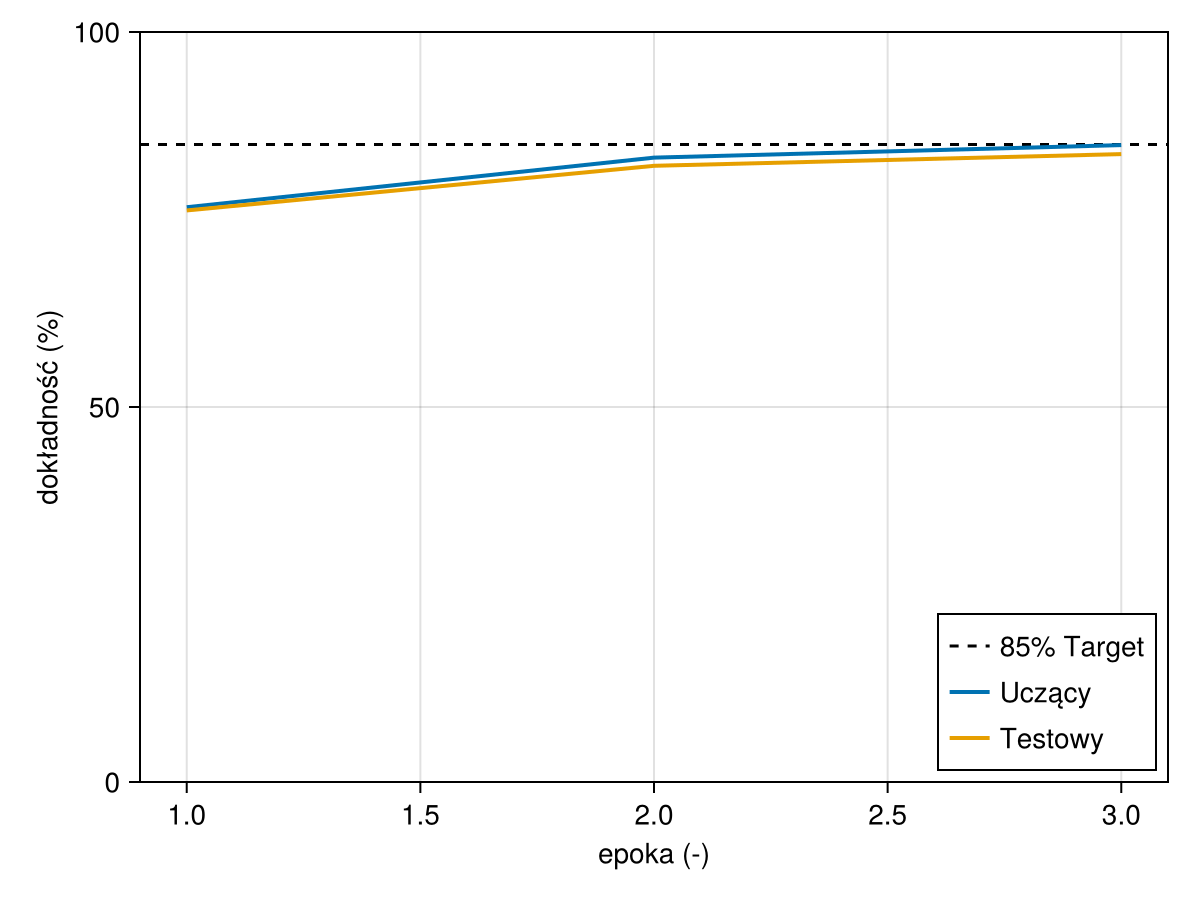

CairoMakie.Screen{IMAGE}


In [6]:
println("[x] Generowanie wykresów...")
using CairoMakie

fig = Figure()
gca = Axis(fig[1,1], xlabel="epoka (-)", ylabel="dokładność (%)")
hlines!(85, linestyle=:dash, color=:black, label="85% Target")

lines!(gca, 1:epochs, accuracy[:,1], linewidth=2, label="Uczący")
lines!(gca, 1:epochs, accuracy[:,2], linewidth=2, label="Testowy")
ylims!(gca, (0, 100))
axislegend(gca, position = :rb)

display(fig)